# Detecção de JPEG Ghosts

Implementação do artigo:

[1] H. Farid, “Exposing Digital Forgeries From JPEG Ghosts”, IEEE Transactions on Information Forensics and Security, vol. 4, nº 1, p. 154–160, mar. 2009, doi: 10.1109/TIFS.2008.2012215.

Autor: Paulo Max Gil Innocencio Reis 

Email: paulo.pmgir@pf.gov.br

Serviço de Perícias em Audiovisual e Eletrônicos - INC/DITEC

*Recompressão de imagens JPEG em qualidades distintas podem deixar artefatos mensuráveis no domínio dos pixels*

# Carregando pacotes

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from multiprocessing import cpu_count
import gc
from scipy.signal import convolve2d

# Definindo funções

In [35]:
def process_single_quality(image, Q, b):
    original_float = image.astype(np.float32)
    kernel = np.ones((b, b), np.float32) / (b * b)
    
    # Compressão da imagem em formato JPEG
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), Q]
    _, encoded_img = cv2.imencode('.jpg', image, encode_param)
    compressed_img = cv2.imdecode(encoded_img, 1).astype(np.float32)
    
    del encoded_img
    gc.collect()
    # Cálculo da diferença quadrática
    diff = (original_float - compressed_img) ** 2
    del original_float, compressed_img
    gc.collect()
    # Convolução em cada canal de cor
    convolved = np.zeros_like(diff)
    for i in range(3):  # Para cada canal de cor
        convolved[:, :, i] = cv2.filter2D(diff[:, :, i], -1, kernel)
    del diff
    gc.collect()
    # Média entre os canais de cor e normalização
    averaged = np.mean(convolved, axis=2)
    del convolved
    
    normalized = (averaged - np.min(averaged)) / (np.max(averaged) - np.min(averaged))
    # Liberar memória intermediária
    del averaged
    gc.collect()
    
    return normalized

def process_image(image, Qmin, Qmax, step, b, n_jobs=-1):
    qualities = range(Qmin, Qmax + 1, step)
    images = Parallel(n_jobs=n_jobs, backend='loky')(delayed(process_single_quality)(image, Q, b) for Q in (qualities))
    return images

def compute_metric(image, K):
    height, width = image.shape
    metrics = np.zeros_like(image, dtype=np.float32)
    integral_image = cv2.integral(image, sdepth=cv2.CV_32F)
    global_mean = np.mean(image)
    
    # Calculando as coordenadas para as bordas das janelas de vizinhança
    i_indices = np.arange(height)
    j_indices = np.arange(width)
    i_min = np.maximum(i_indices[:, None] - K // 2, 0)
    i_max = np.minimum(i_indices[:, None] + K // 2, height - 1)
    j_min = np.maximum(j_indices[None, :] - K // 2, 0)
    j_max = np.minimum(j_indices[None, :] + K // 2, width - 1)
    
    # Usando broadcast para calcular as somas das vizinhanças
    neighborhood_sum = (
        integral_image[i_max + 1, j_max + 1]
        - integral_image[i_max + 1, j_min]
        - integral_image[i_min, j_max + 1]
        + integral_image[i_min, j_min]
    )
    
    # Área da vizinhança
    neighborhood_area = (i_max - i_min + 1) * (j_max - j_min + 1)
    mean_neighborhood = neighborhood_sum / neighborhood_area
    
    if global_mean != 0:
        # Cálculo da média da área fora da vizinhança
        total_pixels = height * width
        mean_non_neighborhood = (global_mean * total_pixels - neighborhood_sum) / (total_pixels - neighborhood_area)
        metrics = mean_neighborhood / mean_non_neighborhood
    else:
        metrics.fill(0)
    
    # Liberar memória intermediária
    del integral_image, i_indices, j_indices, i_min, i_max, j_min, 
    return metrics

def generate_shifted_images(image):
    height, width, _ = image.shape
    shifted_images = []
    for dx in range(8):
        for dy in range(8):
            shifted_image = image[dy:height, dx:width]
            shifted_images.append((shifted_image, dx, dy))
    return shifted_images

# Definindo parâmetros e limitando processamento paralelo


#### b     = tamanho do bloco elementar
#### K     = vizinhança de integração.
#### Q min = qualidade mínima
#### Q max = qualidade máxima
#### setep = passo de busca
#### num_cores = número de núcleos d eprocessamento a utilizar.



In [36]:
# Definição dos parâmetros
b = 16
K = 3
Qmin = 50
Qmax = 100
step = 10

# Verificar o número de núcleos disponíveis
num_cores = 2# cpu_count()
print(f"Número de núcleos disponíveis: {num_cores}")



Número de núcleos disponíveis: 2


# Carregando imagem, definindo busca por deslocamento e gerando versões deslocadas

In [44]:
# Carregar a imagem original
image = cv2.imread('loteria_recortada_2.png')
shift_search=True

# Gerar versões deslocadas da imagem
shifted_images = generate_shifted_images(image)

# Processando as imagens nas qualidades de entrada 

#### As imagens serão processadas paralelamente em todas os 64 deslocamentos

In [45]:
# Processar todas as imagens deslocadas e calcular métricas em paralelo
all_metrics_results = []
dx_dy_info = []
best_processed_images = []
best_metric_images = []
quality_best_metrics = []

if shift_search:
    for shifted_image, dx, dy in tqdm(shifted_images):
        processed_images = process_image(shifted_image, Qmin, Qmax, step, b, n_jobs=num_cores)
        metrics_results = Parallel(n_jobs=num_cores, backend='loky')(delayed(compute_metric)(img, K) for img in processed_images)
        
        # Armazenar apenas o melhor resultado de cada conjunto
        max_metric = -np.inf
        best_image = None
        best_metric_image= None
        best_Q = None
        
        for metric, processed_image in zip(metrics_results, processed_images):
            if np.max(metric) > max_metric:
                max_metric = np.max(metric)
                best_image = processed_image
                best_metric_image=metric                
                
                
        all_metrics_results.append(max_metric)
        best_processed_images.append(best_image)
        best_metric_images.append(best_metric_image)
        quality_best_metrics.append(best_Q)
        dx_dy_info.append((dx, dy))
        
    # Liberar memória intermediária
    del processed_images, metrics_results, best_image, best_metric_image
    gc.collect()

    # Identificar a imagem com o maior valor de mé40trica
    max_metric_value = max(all_metrics_results)
    best_index = all_metrics_results.index(max_metric_value)
    best_dx, best_dy = dx_dy_info[best_index]

    best_metric_image = best_metric_images[best_index]
    best_normalized_image = best_processed_images[best_index]
    quality_best = quality_best_metrics[best_index]

        

else:
    processed_images = process_image(shifted_image, Qmin, Qmax, step, b, n_jobs=num_cores)
    metrics_results = Parallel(n_jobs=num_cores, backend='loky')(delayed(compute_metric)(img, K) for img in tqdm(processed_images))

    for metric, processed_image in zip(metrics_results, processed_images):
            max_metric_value = np.max(metric)
            best_metric_image = metric
            best_normalized_image = processed_image
            best_dx, best_dy = [-1, -1]



print(f"Melhor valor de métrica: {max_metric_value}")
print(f"Deslocamento dx: {best_dx}, dy: {best_dy}")
print(f"Qualidade maelhor métrica: {quality_best}")

100%|██████████| 64/64 [00:44<00:00,  1.42it/s]

Melhor valor de métrica: 10.652228040293851
Deslocamento dx: 1, dy: 6
Qualidade maelhor métrica: None


# A imagem de maior métrica de  discrepância nas buscas é plotada.

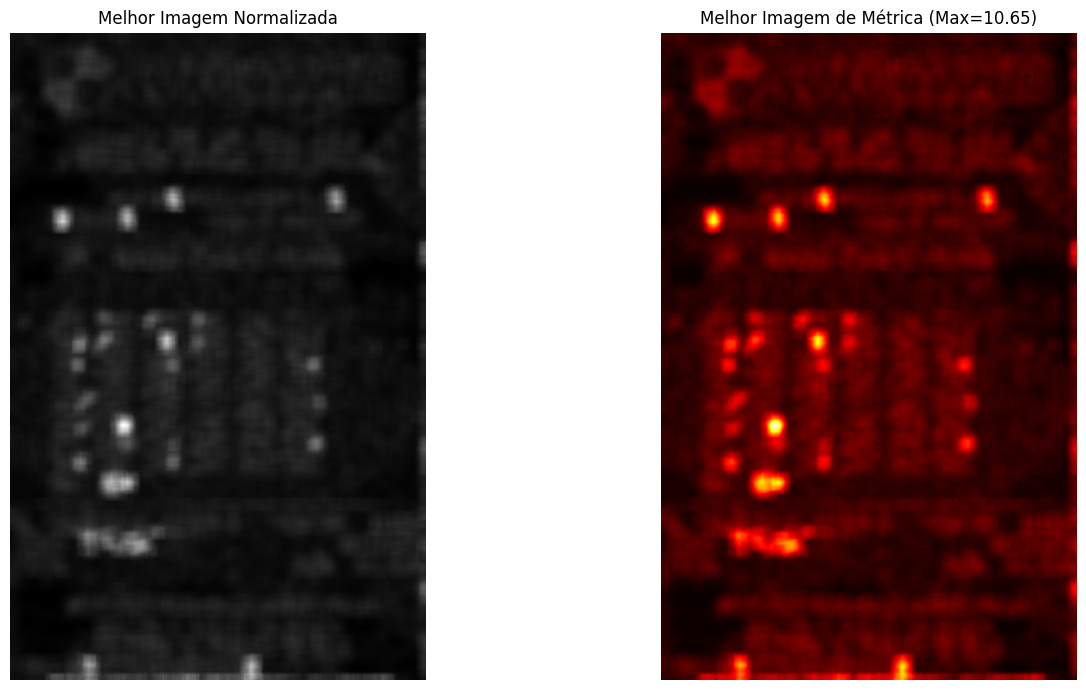

In [46]:
 #Plotar os resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(best_normalized_image, cmap='gray')
axes[0].set_title('Melhor Imagem Normalizada')
axes[0].axis('off')

# Definir o valor máximo do heatmap como K^2
axes[1].imshow(best_metric_image, cmap='hot', vmin=0, vmax=max_metric_value)
axes[1].set_title(f'Melhor Imagem de Métrica (Max={max_metric_value:.2f})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Visualização do conjunto de imagens em todos os deslocamentos, na qualidade de maior métrica.

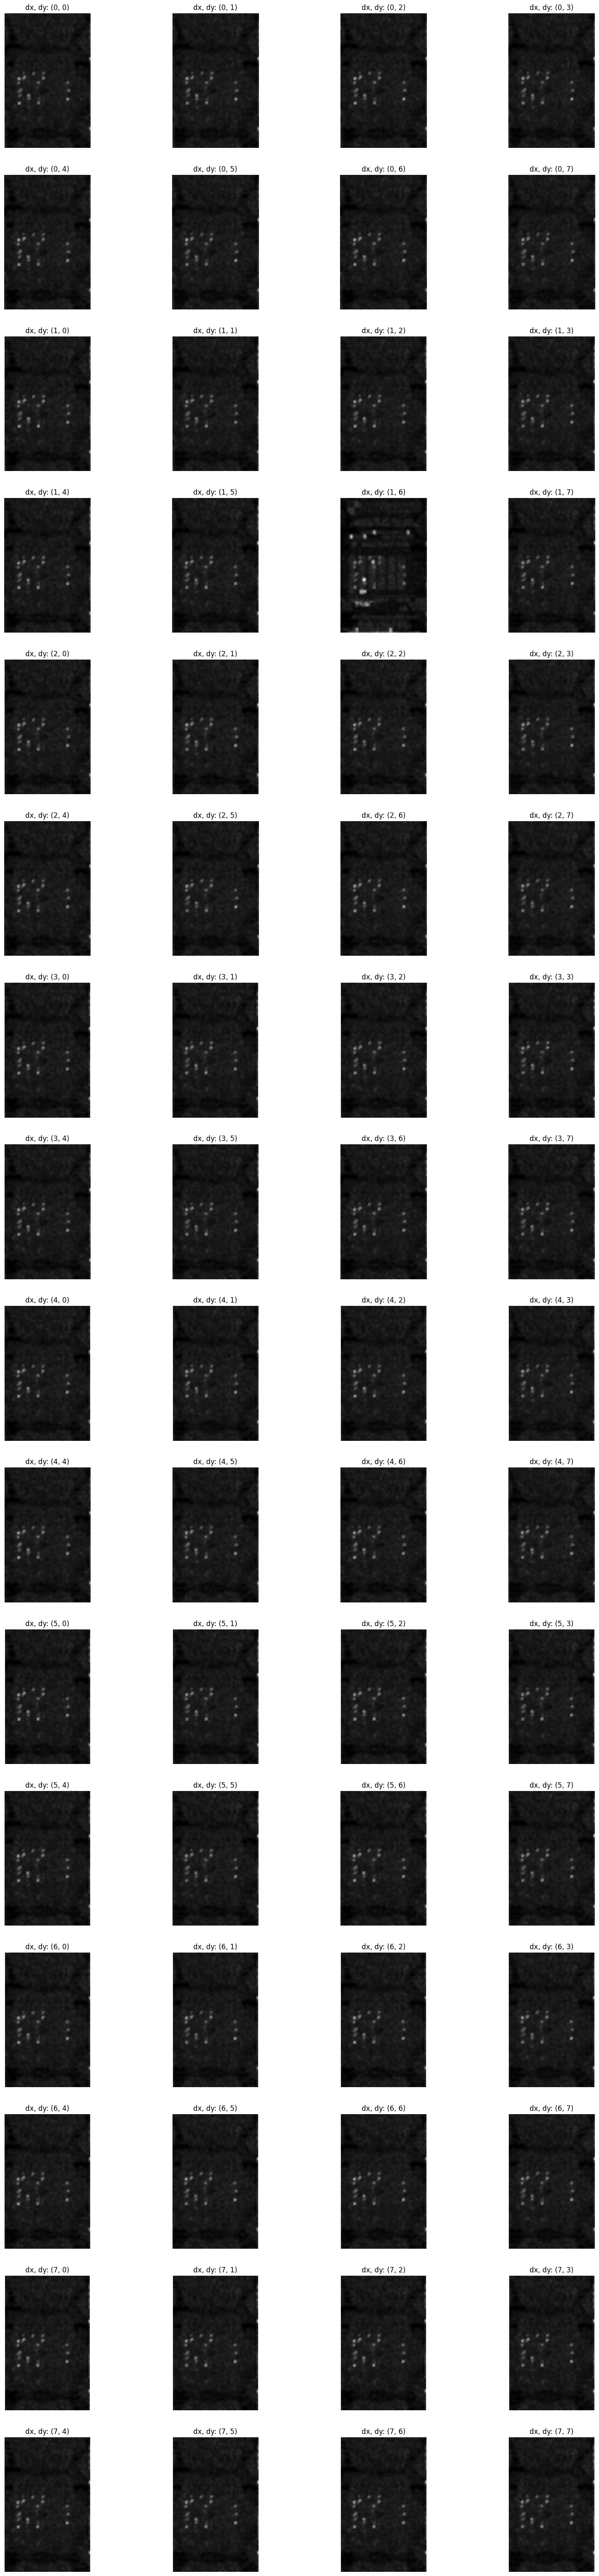

In [47]:
#Plotar os resultados
fig, axes = plt.subplots(16, 4, figsize=(20, 80))

# Flatten the 2D array of axes to simplify indexing
axes = axes.flatten()  

    
for i in range(len(best_processed_images)):
    im= best_metric_images[i]
    axes[i].imshow(im, cmap='gray',vmin=0, vmax=max_metric_value)
    axes[i].set_title(f"dx, dy: {dx_dy_info[i]}")
    axes[i].axis('off')

plt.show()  